In [80]:
import math
import pandas as pd
import torch
from torch import nn
import os
import hashlib
import zipfile
import collections
from torch.utils import data
import time
import matplotlib.pyplot as plt
from matplotlib_inline import backend_inline
from IPython import display

In [51]:
class PositionWiseFFN(nn.Module):
    """基于位置的前馈网络"""
    def __init__(self,ffn_num_input,ffn_num_hiddens,ffn_num_outputs,**kwargs):
        super(PositionWiseFFN,self).__init__(**kwargs)
        self.dense1 = nn.Linear(ffn_num_input,ffn_num_hiddens)
        self.relu = nn.ReLU()
        self.dense2 = nn.Linear(ffn_num_hiddens,ffn_num_outputs)
    def forward(self,X):
        return self.dense2(self.relu(self.dense1(X)))

In [52]:
ffn = PositionWiseFFN(4,4,8)
ffn.eval()
ffn(torch.ones((2,3,4)))[0]

tensor([[ 0.5052, -0.4029, -0.2839, -0.4120, -0.3832,  0.2594,  0.5205, -0.2662],
        [ 0.5052, -0.4029, -0.2839, -0.4120, -0.3832,  0.2594,  0.5205, -0.2662],
        [ 0.5052, -0.4029, -0.2839, -0.4120, -0.3832,  0.2594,  0.5205, -0.2662]],
       grad_fn=<SelectBackward0>)

In [53]:
ln = nn.LayerNorm(2)
bn = nn.BatchNorm1d(2)
X = torch.tensor([[1,2],[2,3]],dtype=torch.float32)
# 在训练模式下计算X的均值和方差
print('layer norm:',ln(X),'\batch norm:',bn(X))

layer norm: tensor([[-1.0000,  1.0000],
        [-1.0000,  1.0000]], grad_fn=<NativeLayerNormBackward0>)atch norm: tensor([[-1.0000, -1.0000],
        [ 1.0000,  1.0000]], grad_fn=<NativeBatchNormBackward0>)


In [54]:
class AddNorm(nn.Module):
    """残差连接后进行层规范化"""
    def __init__(self,normalized_shape,dropout,**kwargs):
        super(AddNorm,self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(normalized_shape)
    def forward(self,X,Y):
        return self.ln(self.dropout(Y)+X)

In [55]:
add_norm = AddNorm([3,4],0.5)
add_norm.eval()
add_norm(torch.ones((2,3,4)),torch.ones((2,3,4))).shape

torch.Size([2, 3, 4])

In [56]:
def sequence_mask(X,valid_len,value=0):
    """在序列中屏蔽不相关的项"""
    maxlen = X.size(1)
    mask = torch.arange((maxlen),dtype=torch.float32,device=X.device)[None,:]<valid_len[:,None]
    X[~mask] = value
    return X

def masked_softmax(X,valid_lens):
    """通过在最后一个轴上掩蔽元素来执行softmax操作"""
    # X:3D张量，valid_lens:1D或2D张量
    if valid_lens is None:
        return nn.functional.softmax(X,dim=-1)
    else:
        shape = X.shape
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens,shape[1])
        else:
            valid_lens = valid_lens.reshape(-1)
        # 最后一个轴上被掩蔽的元素使用一个非常大的负值替换，从而其softmax输出为0
        X = sequence_mask(X.reshape(-1,shape[-1]),valid_lens,value=-1e6)
        return nn.functional.softmax(X.reshape(shape),dim=-1)

class DotProductAttention(nn.Module):
    """缩放点积注意力"""
    def __init__(self,dropout,**kwargs):
        super(DotProductAttention,self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)
    def forward(self,queries,keys,values,valid_lens=None):
        d = queries.shape[-1]
        scores = torch.bmm(queries,keys.transpose(1,2))/math.sqrt(d)
        self.attention_weights = masked_softmax(scores,valid_lens)
        return torch.bmm(self.dropout(self.attention_weights),values)

def transpose_qkv(X,num_heads):
    """为了多头注意力的并行计算而变换形状"""
    X = X.reshape(X.shape[0],X.shape[1],num_heads,-1)
    X = X.permute(0,2,1,3)
    return X.reshape(-1,X.shape[2],X.shape[3])

def transpose_output(X,num_heads):
    """反转transpose_qkv函数的操作"""
    X = X.reshape(-1,num_heads,X.shape[1],X.shape[2])
    X = X.permute(0,2,1,3)
    return X.reshape(X.shape[0],X.shape[1],-1)

class MultiHeadAttention(nn.Module):
    def __init__(self,key_size,query_size,value_size,num_hiddens,num_heads,dropout,bias=False,**kwargs):
        super(MultiHeadAttention,self).__init__(**kwargs)
        self.num_heads = num_heads
        self.attention = DotProductAttention(dropout)
        self.W_q = nn.Linear(query_size,num_hiddens,bias=bias)
        self.W_k = nn.Linear(key_size,num_hiddens,bias=bias)
        self.W_v = nn.Linear(value_size,num_hiddens,bias=bias)
        self.W_o = nn.Linear(num_hiddens,num_hiddens,bias=bias)

    def forward(self,queries,keys,values,valid_lens):
        queries = transpose_qkv(self.W_q(queries),self.num_heads)
        keys = transpose_qkv(self.W_k(keys),self.num_heads)
        values = transpose_qkv(self.W_v(values),self.num_heads)
        if valid_lens is not None:
            valid_lens = torch.repeat_interleave(valid_lens,repeats = self.num_heads,dim=0)
        output = self.attention(queries,keys,values,valid_lens)
        output_concat = transpose_output(output,self.num_heads)
        return self.W_o(output_concat)

In [57]:
class EncoderBlock(nn.Module):
    """Transformer编码器块"""
    def __init__(self,key_size,query_size,value_size,num_hiddens,norm_shape,ffn_num_input,ffn_num_hiddens,num_heads,dropout,use_bias=False,**kwargs):
        super(EncoderBlock,self).__init__(**kwargs)
        self.attention = MultiHeadAttention(key_size,query_size,value_size,num_hiddens,num_heads,dropout,use_bias)
        self.addnorm1 = AddNorm(norm_shape,dropout)
        self.ffn = PositionWiseFFN(ffn_num_input,ffn_num_hiddens,num_hiddens)
        self.addnorm2 = AddNorm(norm_shape,dropout)
    def forward(self,X,valid_lens):
        Y = self.addnorm1(X,self.attention(X,X,X,valid_lens))
        return self.addnorm2(Y,self.ffn(Y))

In [58]:
X = torch.ones((2, 100, 24))
valid_lens = torch.tensor([3, 2])
encoder_blk = EncoderBlock(24, 24, 24, 24, [100, 24], 24, 48, 8, 0.5)
encoder_blk.eval()
encoder_blk(X, valid_lens).shape

torch.Size([2, 100, 24])

In [59]:
class Encoder(nn.Module):
    """编码器解码器架构的基本编码器接口"""
    def __init__(self,**kwargs):
        super(Encoder,self).__init__(**kwargs)
    
    def forward(self,X,*args):
        raise NotImplementedError

In [60]:
class PositionalEncoding(nn.Module):
    """位置编码"""
    def __init__(self,num_hiddens,dropout,max_len=1000):
        super(PositionalEncoding,self).__init__()
        self.dropout = nn.Dropout(dropout)
        # 创建一个足够长的P
        self.P = torch.zeros((1,max_len,num_hiddens))
        X = torch.arange(max_len,dtype=torch.float32).reshape(-1,1)/torch.pow(10000,torch.arange(0,num_hiddens,2,dtype=torch.float32)/num_hiddens)
        self.P[:,:,0::2] = torch.sin(X)
        self.P[:,:,1::2] = torch.cos(X)

    def forward(self,X):
        X = X + self.P[:,:X.shape[1],:].to(X.device)
        return self.dropout(X)

In [61]:
class TransformerEncoder(Encoder):
    """Transformer编码器"""
    def __init__(self,vocab_size,key_size,query_size,value_size,num_hiddens,norm_shape,ffn_num_input,ffn_num_hiddens,num_heads,num_layers,dropout,use_bias=False,**kwargs):
        super(TransformerEncoder,self).__init__(**kwargs)
        self.num_hiddens = num_hiddens
        self.embedding = nn.Embedding(vocab_size,num_hiddens)
        self.pos_encoding = PositionalEncoding(num_hiddens,dropout)
        self.blks = nn.Sequential()
        for i in range(num_layers):
            self.blks.add_module("block"+str(i),EncoderBlock(key_size,query_size,value_size,num_hiddens,norm_shape,ffn_num_input,ffn_num_hiddens,num_heads,dropout,use_bias))
            
    def forward(self,X,valid_lens,*args):
        # 因为位置编码值范围在-1~1，所以嵌入值乘以嵌入维度的平方根进行缩放，再与位置编码相加
        X = self.pos_encoding(self.embedding(X)*math.sqrt(self.num_hiddens))
        self.attention_weights = [None]*len(self.blks)
        for i,blk in enumerate(self.blks):
            X = blk(X,valid_lens)
            self.attention_weights[i] = blk.attention.attention.attention_weights
        return X

In [62]:
encoder = TransformerEncoder(200, 24, 24, 24, 24, [100, 24], 24, 48, 8, 2, 0.5)
encoder.eval()
encoder(torch.ones((2, 100), dtype=torch.long), valid_lens).shape

torch.Size([2, 100, 24])

In [63]:
class DecoderBlock(nn.Module):
    """解码器中第i个块"""
    def __init__(self,key_size,query_size,value_size,num_hiddens,norm_shape,ffn_num_input,ffn_num_hiddens,num_heads,dropout,i,**kwargs):
        super(DecoderBlock,self).__init__(**kwargs)
        self.i = i
        self.attention1 = MultiHeadAttention(key_size,query_size,value_size,num_hiddens,num_heads,dropout)
        self.addnorm1 = AddNorm(norm_shape,dropout)
        self.attention2 = MultiHeadAttention(key_size,query_size,value_size,num_hiddens,num_heads,dropout)
        self.addnorm2 = AddNorm(norm_shape,dropout)
        self.ffn = PositionWiseFFN(ffn_num_input,ffn_num_hiddens,num_hiddens)
        self.addnorm3 = AddNorm(norm_shape,dropout)
    def forward(self,X,state):
        enc_outputs,enc_valid_lens = state[0],state[1]
        # 训练阶段，输出序列的所有词元都在同一时间处理
        # 因此state[2][self.i]初始化为None
        # 预测阶段，输出序列是通过词元一个接着一个解码的
        # 因此state[2][self.i]包含直到当前时间步第i个块解码的输出表示
        if state[2][self.i] is None:
            key_values = X
        else:
            key_values = torch.cat((state[2][self.i],X),axis=1)
        state[2][self.i] = key_values
        if self.training:
            batch_size,num_steps,_ = X.shape
            # dec_valid_lens的开头：（batch_size,num_steps）
            # 其中每一行是[1,2,...,num_steps]
            dec_valid_lens = torch.arange(1,num_steps+1,device=X.device).repeat(batch_size,1)
        else:
            dec_valid_lens = None

        # 自注意力
        X2 = self.attention1(X,key_values,key_values,dec_valid_lens)
        Y = self.addnorm1(X,X2)
        # 编码器-解码器注意力
        # enc_outputs的开头:（batch_size,num_steps,num_hiddens）
        Y2 = self.attention2(Y,enc_outputs,enc_outputs,enc_valid_lens)
        Z = self.addnorm2(Y,Y2)
        return self.addnorm3(Z,self.ffn(Z)),state

In [64]:
decoder_blk = DecoderBlock(24, 24, 24, 24, [100, 24], 24, 48, 8, 0.5, 0)
decoder_blk.eval()
X = torch.ones((2, 100, 24))
state = [encoder_blk(X, valid_lens), valid_lens, [None]]
decoder_blk(X, state)[0].shape

torch.Size([2, 100, 24])

In [65]:
class Decoder(nn.Module):
    """编码器解码器架构的基本解码器接口"""
    def __init__(self,**kwargs):
        super(Decoder,self).__init__(**kwargs)
    def init_state(self,enc_outputs,*args):
        raise NotImplementedError
    def forward(self,X,state):
        raise NotImplementedError

class AttentionDecoder(Decoder):
    """带有注意力机制解码器的基本接口"""
    def __init__(self,**kwargs):
        super(AttentionDecoder,self).__init__(**kwargs)
    @property
    def attention_weights(self):
        raise NotImplementedError

class EncoderDecoder(nn.Module):
    """编码器-解码器架构的基类"""
    def __init__(self,encoder,decoder,**kwargs):
        super(EncoderDecoder,self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
    def forward(self,enc_X,dec_X,*args):
        enc_outputs = self.encoder(enc_X,*args)
        dec_state = self.decoder.init_state(enc_outputs,*args)
        return self.decoder(dec_X,dec_state)

In [66]:
class TransformerDecoder(AttentionDecoder):
    def __init__(self, vocab_size, key_size, query_size, value_size,num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens,num_heads, num_layers, dropout, **kwargs):
        super(TransformerDecoder, self).__init__(**kwargs)
        self.num_hiddens = num_hiddens
        self.num_layers = num_layers
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_layers):
            self.blks.add_module("block"+str(i),
                DecoderBlock(key_size, query_size, value_size, num_hiddens,norm_shape, ffn_num_input, ffn_num_hiddens,num_heads, dropout, i))
        self.dense = nn.Linear(num_hiddens, vocab_size)

    def init_state(self, enc_outputs, enc_valid_lens, *args):
        return [enc_outputs, enc_valid_lens, [None] * self.num_layers]

    def forward(self, X, state):
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))
        self._attention_weights = [[None] * len(self.blks) for _ in range (2)]
        for i, blk in enumerate(self.blks):
            X, state = blk(X, state)
            # 解码器自注意力权重
            self._attention_weights[0][i] = blk.attention1.attention.attention_weights
            # “编码器－解码器”自注意力权重
            self._attention_weights[1][i] = blk.attention2.attention.attention_weights
        return self.dense(X), state

    @property
    def attention_weights(self):
        return self._attention_weights

In [67]:
class Vocab:
    """文本词表"""
    def __init__(self,tokens=None,min_freq=0,reserved_tokens=None):
        if tokens is None:
            tokens = []
        if reserved_tokens is None:
            reserved_tokens = []
        # 按出现频率排列
        counter = count_corpus(tokens)
        self._token_freqs = sorted(counter.items(),key = lambda x:x[1],reverse=True)
        # 未知词元的索引为0
        self.idx_to_token = ['<unk>'] + reserved_tokens
        self.token_to_idx = {token:idx for idx,token in enumerate(self.idx_to_token)}
        for token,freq in self.token_freqs:
            if freq < min_freq:
                break
            if token not in self.token_to_idx:
                self.idx_to_token.append(token)
                self.token_to_idx[token] = len(self.idx_to_token) - 1

    def __len__(self):
        return len(self.idx_to_token)
        
    # def __getitem__(self,tokens):
    #     if not isinstance(tokens,(list,tuple)):
    #         return self.token_to_idx.get(tokens,self.unk)
    #     return [self.token_to_idx[token] for token in tokens]
    
    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)   # 单个 token 使用 get
        return [self.token_to_idx.get(token, self.unk) for token in tokens]   # 列表推导使用 get
    
    def to_tokens(self,indices):
        if not isinstance(indices,(list,tuple)):
            return self.idx_to_token[indices]
        return [self.idx_to_token[index] for index in indices]
    
    @property
    def unk(self):
        return 0
    @property
    def token_freqs(self):
        return self._token_freqs

def count_corpus(tokens):
    """统计词元出现的频率"""
    # 这里的tokens是一维列表或二维列表
    if len(tokens)==0 or isinstance(tokens[0],list):
        # 将词元列表展平成一个列表
        tokens = [token for line in tokens for token in line]
    return collections.Counter(tokens)

In [68]:
# 9.5 机器翻译与数据集的

DATA_HUB = dict()
DATA_URL = 'http://d2l-data.s3-accelerate.amazonaws.com/'
DATA_HUB['fra-eng'] = (DATA_URL + 'fra-eng.zip','94646ad1522d915e7b0f9296181140edcf86a4f5')

def build_array_nmt(lines, vocab, num_steps):
    """将机器翻译的文本序列转换成小批量"""
    lines = [vocab[l] for l in lines]
    lines = [l + [vocab['<eos>']] for l in lines]
    array = torch.tensor([truncate_pad(l, num_steps, vocab['<pad>']) for l in lines])
    valid_len = (array != vocab['<pad>']).type(torch.int32).sum(1)
    return array, valid_len

def load_array(data_arrays, batch_size, is_train=True):
    """构造一个 PyTorch 数据迭代器"""
    dataset = data.TensorDataset(*data_arrays) # 将输入数据封装为 TensorDataset
    return data.DataLoader(dataset, batch_size, shuffle=is_train) # 返回 DataLoader

def truncate_pad(line, num_steps, padding_token):
    """截断或填充文本序列"""
    if len(line) > num_steps:
        return line[:num_steps]  # 截断
    return line + [padding_token] * (num_steps - len(line))  # 填充

def tokenize_nmt(text, num_examples=None):
    """词元化“英语－法语”数据数据集"""
    source, target = [], []
    for i, line in enumerate(text.split('\n')):
        if num_examples and i > num_examples:
            break
        parts = line.split('\t')
        if len(parts) == 2:
            source.append(parts[0].split(' '))
            target.append(parts[1].split(' '))
    return source, target

def download(name,cache_dir=os.path.join('.','data')):
    "下载一个DATA_HUB中的文件返回本地文件名"
    assert name in DATA_HUB,f"{name}不存在于{DATA_HUB}"
    url,sha1_hash = DATA_HUB[name]
    os.makedirs(cache_dir,exist_ok=True)
    fname = os.path.join(cache_dir,url.split('/')[-1])
    if os.path.exists(fname):
        sha1 = hashlib.sha1()
        with open(fname,'rb') as f:
            while True :
                data = f.read(1048576)
                if not data:
                     break
                sha1.update(data)
        if sha1.hexdigest() == sha1_hash:
            return fname
    print(f'正在从{url}下载{fname}...')
    r =  requests.get(url,stream=True,verify=True)
    with open(fname,'wb') as f:
        f.write(r.content)
    return fname
    
def download_extract(name, folder=None):  #@save
    """下载并解压zip/tar文件"""
    fname = download(name)
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        assert False, '只有zip/tar文件可以被解压缩'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

def read_data_nmt():
    """载入“英语－法语”数据集"""
    data_dir = download_extract('fra-eng')
    with open(os.path.join(data_dir, 'fra.txt'), 'r',encoding='utf-8') as f:
        return f.read()

def preprocess_nmt(text):
    """预处理“英语－法语”数据集"""
    def no_space(char, prev_char):
        return char in set(',.!?') and prev_char != ' '

    # 使用空格替换不间断空格
    # 使用小写字母替换大写字母
    text = text.replace('\u202f', ' ').replace('\xa0', ' ').lower()
    # 在单词和标点符号之间插入空格
    out = [' ' + char if i > 0 and no_space(char, text[i - 1]) else char
           for i, char in enumerate(text)]
    return ''.join(out)

def load_data_nmt(batch_size, num_steps, num_examples=600):
    """返回翻译数据集的迭代器和词表"""
    text = preprocess_nmt(read_data_nmt())
    source, target = tokenize_nmt(text, num_examples)
    src_vocab = Vocab(source, min_freq=2,reserved_tokens=['<pad>', '<bos>', '<eos>'])
    tgt_vocab = Vocab(target, min_freq=2,reserved_tokens=['<pad>', '<bos>', '<eos>'])
    src_array, src_valid_len = build_array_nmt(source, src_vocab, num_steps)
    tgt_array, tgt_valid_len = build_array_nmt(target, tgt_vocab, num_steps)
    data_arrays = (src_array, src_valid_len, tgt_array, tgt_valid_len)
    data_iter = load_array(data_arrays, batch_size)
    return data_iter, src_vocab, tgt_vocab

In [69]:
# 辅助函数：累加器
class Accumulator:
    def __init__(self,n):
        self.data = [0.0]*n
    def add(self,*args):
        self.data = [a+float(b) for a,b in zip(self.data,args)]
    def reset(self):
        self.data = [0.0]*len(self.data)
    def __getitem__(self,idx):
        return self.data[idx]

def grad_clipping(net,theta):
    """截断梯度"""
    if isinstance(net,nn.Module):
        params = [p for p in net.parameters() if p.requires_grad]
    else:
        params = net.params
    norm = torch.sqrt(sum(torch.sum((p.grad**2)) for p in params))
    if norm > theta:
        for param in params:
            param.grad[:] *= theta/norm

def train_seq2seq(net,data_iter,lr,num_epochs,tgt_vocab,device):
    """训练序列到序列模型"""
    def xavier_init_weights(m):
        if type(m) == nn.Linear:
            nn.init.xavier_uniform_(m.weight)
        if type(m) == nn.GRU:
            for param in m._flat_weights_names:
                if "weight" in param:
                    nn.init.xavier_uniform_(m._parameters[param])
    net.apply(xavier_init_weights)
    net.to(device)
    optimizer = torch.optim.Adam(net.parameters(),lr=lr)
    loss = MaskedSoftmaxCELoss()
    net.train()
    animator = Animator(xlabel='epoch',ylabel='loss',xlim=[10,num_epochs])
    for epoch in range(num_epochs):
        timer = Timer()
        metric = Accumulator(2)  # 训练损失总和，词元数量
        for batch in data_iter:
            optimizer.zero_grad()
            X,X_valid_len,Y,Y_valid_len = [x.to(device) for x in batch]
            bos = torch.tensor([tgt_vocab['<bos>']]*Y.shape[0],device=device).reshape(-1,1)
            dec_input = torch.cat([bos,Y[:,:-1]],1)
            Y_hat,_ = net(X,dec_input,X_valid_len)
            l = loss(Y_hat,Y,Y_valid_len)
            l.sum().backward()  # 损失函数的标量进行“反向传播”
            grad_clipping(net,1)
            num_tokens = Y_valid_len.sum()
            optimizer.step()
            with torch.no_grad():
                metric.add(l.sum(),num_tokens)
        if (epoch+1)%10 == 0:
            animator.add(epoch+1,(metric[0]/metric[1],))
    print(f'loss{metric[0]/metric[1]:.3f},{metric[1]/timer.stop():.1f}'f'tokens/sec on {str(device)}')

In [78]:
# 辅助函数：计算时间
class Timer:  #@save
    """记录多次运行时间"""
    def __init__(self):
        self.times = []
        self.start()
    def start(self):
        """启动计时器"""
        self.tik = time.time()
    def stop(self):
        """停止计时器并将时间记录在列表中"""
        self.times.append(time.time() - self.tik)
        return self.times[-1]
    def avg(self):
        """返回平均时间"""
        return sum(self.times) / len(self.times)
    def sum(self):
        """返回时间总和"""
        return sum(self.times)
    def cumsum(self):
        """返回累计时间"""
        return np.array(self.times).cumsum().tolist()

In [74]:
# 辅助函数：绘图用
def use_svg_display():
    """使用svg格式在jupyter中显示绘图"""
    backend_inline.set_matplotlib_formats('svg')

def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """设置matplotlib的轴"""
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    axes.set_xlim(xlim)
    axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()
    
class Animator:  #@save
    """在动画中绘制数据"""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        # 增量地绘制多条线
        if legend is None:
            legend = []
        use_svg_display()
        self.fig, self.axes = plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        # 使用lambda函数捕获参数
        self.config_axes = lambda: set_axes(self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        # 向图表中添加多个数据点
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)

In [70]:
def try_gpu(i=0):
    """如果存在，则返回gpu(i)，否则返回cpu()"""
    if torch.cuda.device_count()>=i+1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

# 辅助函数：累加器
class Accumulator:
    def __init__(self,n):
        self.data = [0.0]*n
    def add(self,*args):
        self.data = [a+float(b) for a,b in zip(self.data,args)]
    def reset(self):
        self.data = [0.0]*len(self.data)
    def __getitem__(self,idx):
        return self.data[idx]

def grad_clipping(net,theta):
    """截断梯度"""
    if isinstance(net,nn.Module):
        params = [p for p in net.parameters() if p.requires_grad]
    else:
        params = net.params
    norm = torch.sqrt(sum(torch.sum((p.grad**2)) for p in params))
    if norm > theta:
        for param in params:
            param.grad[:] *= theta/norm

def train_seq2seq(net,data_iter,lr,num_epochs,tgt_vocab,device):
    """训练序列到序列模型"""
    def xavier_init_weights(m):
        if type(m) == nn.Linear:
            nn.init.xavier_uniform_(m.weight)
        if type(m) == nn.GRU:
            for param in m._flat_weights_names:
                if "weight" in param:
                    nn.init.xavier_uniform_(m._parameters[param])
    net.apply(xavier_init_weights)
    net.to(device)
    optimizer = torch.optim.Adam(net.parameters(),lr=lr)
    loss = MaskedSoftmaxCELoss()
    net.train()
    animator = Animator(xlabel='epoch',ylabel='loss',xlim=[10,num_epochs])
    for epoch in range(num_epochs):
        timer = Timer()
        metric = Accumulator(2)  # 训练损失总和，词元数量
        for batch in data_iter:
            optimizer.zero_grad()
            X,X_valid_len,Y,Y_valid_len = [x.to(device) for x in batch]
            bos = torch.tensor([tgt_vocab['<bos>']]*Y.shape[0],device=device).reshape(-1,1)
            dec_input = torch.cat([bos,Y[:,:-1]],1)
            Y_hat,_ = net(X,dec_input,X_valid_len)
            l = loss(Y_hat,Y,Y_valid_len)
            l.sum().backward()  # 损失函数的标量进行“反向传播”
            grad_clipping(net,1)
            num_tokens = Y_valid_len.sum()
            optimizer.step()
            with torch.no_grad():
                metric.add(l.sum(),num_tokens)
        if (epoch+1)%10 == 0:
            animator.add(epoch+1,(metric[0]/metric[1],))
    print(f'loss{metric[0]/metric[1]:.3f},{metric[1]/timer.stop():.1f}'f'tokens/sec on {str(device)}')

In [72]:
def sequence_mask(X,valid_len,value=0):
    """在序列中屏蔽不相关的项"""
    maxlen = X.size(1)
    mask = torch.arange((maxlen),dtype=torch.float32,device=X.device)[None,:]<valid_len[:,None]
    X[~mask] = value
    return X

class MaskedSoftmaxCELoss(nn.CrossEntropyLoss):
    """带屏蔽的softmax交叉熵损失函数"""
    # pred的形状为（batch_size,num_steps,vocab_size）
    # label的形状为（batch_size,num_steps）
    # valid_len的形状为（batch_size,）
    def forward(self,pred,label,valid_len):
        weights = torch.ones_like(label)
        weights = sequence_mask(weights,valid_len)
        self.reduction='none'
        unweighted_loss = super(MaskedSoftmaxCELoss,self).forward(pred.permute(0,2,1),label)
        weighted_loss = (unweighted_loss*weights).mean(dim=1)
        return weighted_loss

loss0.031,3091.7tokens/sec on cuda:0


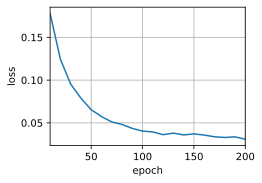

In [81]:
num_hiddens, num_layers, dropout, batch_size, num_steps = 32, 2, 0.1, 64, 10
lr, num_epochs, device = 0.005, 200, try_gpu()
ffn_num_input, ffn_num_hiddens, num_heads = 32, 64, 4
key_size, query_size, value_size = 32, 32, 32
norm_shape = [32]

train_iter, src_vocab, tgt_vocab = load_data_nmt(batch_size, num_steps)

encoder = TransformerEncoder(
    len(src_vocab), key_size, query_size, value_size, num_hiddens,
    norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
    num_layers, dropout)
decoder = TransformerDecoder(
    len(tgt_vocab), key_size, query_size, value_size, num_hiddens,
    norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
    num_layers, dropout)
net = EncoderDecoder(encoder, decoder)
train_seq2seq(net, train_iter, lr, num_epochs, tgt_vocab, device)

In [83]:
def bleu(pred_seq,label_seq,k):
    """计算BLEU"""
    pred_tokens,label_tokens = pred_seq.split(' '),label_seq.split(' ')
    len_pred,len_label = len(pred_tokens),len(label_tokens)
    score = math.exp(min(0,1-len_label/len_pred))
    for n in range(1,k+1):
        num_matches,label_subs = 0,collections.defaultdict(int)
        for i in range(len_label-n+1):
            label_subs[' '.join(label_tokens[i:i+n])]+=1
        for i in range(len_pred-n+1):
            if label_subs[' '.join(pred_tokens[i:i+n])]>0:
                num_matches += 1
                label_subs[' '.join(pred_tokens[i:i+n])]-=1
        score *= math.pow(num_matches/(len_pred-n+1),math.pow(0.5,n))
    return score
    
def predict_seq2seq(net,src_sentence,src_vocab,tgt_vocab,num_steps,device,save_attention_weights=False):
    """序列到序列模型的预测"""
    # 在预测时将net设置为评估模式
    net.eval()
    src_tokens = src_vocab[src_sentence.lower().split(' ')]+[src_vocab['<eos>']]
    enc_valid_len = torch.tensor([len(src_tokens)],device=device)
    src_tokens = truncate_pad(src_tokens,num_steps,src_vocab['<pad>'])
    # 添加批量轴
    enc_X = torch.unsqueeze(torch.tensor(src_tokens,dtype=torch.long,device=device),dim=0)
    enc_outputs = net.encoder(enc_X,enc_valid_len)
    dec_state = net.decoder.init_state(enc_outputs,enc_valid_len)
    # 添加批量轴
    dec_X = torch.unsqueeze(torch.tensor([tgt_vocab['<bos>']],dtype=torch.long,device=device),dim=0)
    output_seq,attention_weight_seq = [],[]
    for _ in range(num_steps):
        Y,dec_state = net.decoder(dec_X,dec_state)
        # 我们使用预测可能性最大的词元，作为解码器在下一个时间步的输入
        dec_X = Y.argmax(dim=2)
        pred = dec_X.squeeze(dim=0).type(torch.int32).item()
        # 保存注意力权重
        if save_attention_weights:
            attention_weight_seq.append(net.decoder.attention_weights)
        # 一旦序列结束词元被预测，输出序列的生成就完成了
        if pred == tgt_vocab['<eos>']:
            break
        output_seq.append(pred)
    return ' '.join(tgt_vocab.to_tokens(output_seq)),attention_weight_seq

In [85]:
engs = ['go .', "i lost .", 'he\'s calm .', 'i\'m home .']
fras = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']
for eng, fra in zip(engs, fras):
    translation, dec_attention_weight_seq = predict_seq2seq(net, eng, src_vocab, tgt_vocab, num_steps, device, True)
    print(f'{eng} => {translation}, ',f'bleu {bleu(translation, fra, k=2):.3f}')

go . => va !,  bleu 1.000
i lost . => j'ai perdu .,  bleu 1.000
he's calm . => il est riche .,  bleu 0.658
i'm home . => je suis chez moi .,  bleu 1.000


In [86]:
enc_attention_weights = torch.cat(net.encoder.attention_weights, 0).reshape((num_layers, num_heads,-1, num_steps))
enc_attention_weights.shape

torch.Size([2, 4, 10, 10])

In [89]:
def show_heatmaps(matrices,xlabel,ylabel,titles=None,figsize=(2.5,2.5),cmap='Reds'):
    """显示矩阵热图"""
    use_svg_display()
    num_rows,num_cols = matrices.shape[0],matrices.shape[1]
    fig,axes = plt.subplots(num_rows,num_cols,figsize=figsize,sharex=True,sharey=True,squeeze=False)
    for i,(row_axes,row_matrices) in enumerate(zip(axes,matrices)):
        for j,(ax,matrix) in enumerate(zip(row_axes,row_matrices)):
            pcm = ax.imshow(matrix.detach().numpy(),cmap=cmap)
            if i == num_rows-1:
                ax.set_xlabel(xlabel)
            if j == 0:
                ax.set_ylabel(ylabel)
            if titles:
                ax.set_title(titles[j])
    fig.colorbar(pcm,ax=axes,shrink=0.6)

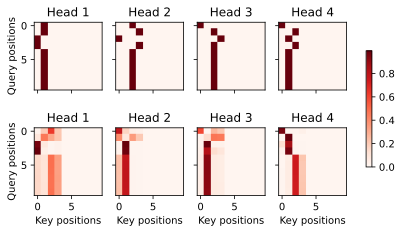

In [90]:
show_heatmaps(enc_attention_weights.cpu(), xlabel='Key positions',ylabel='Query positions', titles=['Head %d' % i for i in range(1, 5)],figsize=(7, 3.5))

In [91]:
dec_attention_weights_2d = [head[0].tolist() for step in dec_attention_weight_seq for attn in step for blk in attn for head in blk]
dec_attention_weights_filled = torch.tensor(pd.DataFrame(dec_attention_weights_2d).fillna(0.0).values)
dec_attention_weights = dec_attention_weights_filled.reshape((-1, 2, num_layers, num_heads, num_steps))
dec_self_attention_weights, dec_inter_attention_weights = dec_attention_weights.permute(1, 2, 3, 0, 4)
dec_self_attention_weights.shape, dec_inter_attention_weights.shape

(torch.Size([2, 4, 6, 10]), torch.Size([2, 4, 6, 10]))

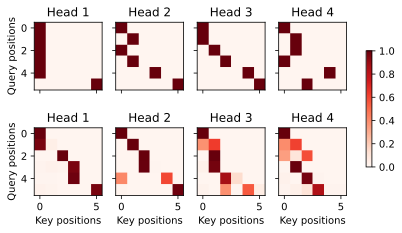

In [92]:
show_heatmaps(dec_self_attention_weights[:, :, :, :len(translation.split()) + 1],xlabel='Key positions', ylabel='Query positions',titles=['Head %d' % i for i in range(1, 5)], figsize=(7, 3.5))

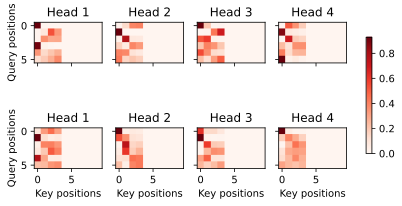

In [93]:
show_heatmaps(dec_inter_attention_weights, xlabel='Key positions',ylabel='Query positions', titles=['Head %d' % i for i in range(1, 5)],figsize=(7, 3.5))